##### Data preprocessing (Winter months - January)

##### Load in and read the pickle files (Solar Irradiance)

In [ ]:
import pickle
import pandas as pd
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [ ]:
# Combined Data from 2013 - 2019 (7 years)

error_data = {}

for year in range(2013, 2021):
  with open(f'error_solar_{year}.pickle', 'rb') as file:
    error_data[f'{year}'] = pickle.load(file)

ed = [error_data['2013'], error_data['2014'], error_data['2015'], error_data['2016'], error_data['2017'], error_data['2018'], error_data['2019']]

merged_error_solar = pd.concat(ed, ignore_index = False)

merged_error_solar = merged_error_solar.reset_index()

In [ ]:
merged_error_solar

,Date,error_solar
0,2013-01-01 05:00:00,114.431946
1,2013-01-01 06:00:00,17.820526
2,2013-01-01 07:00:00,31.141602
3,2013-01-01 08:00:00,15.448059
4,2013-01-01 09:00:00,120.551941
...,...,...
30250,2019-12-31 15:00:00,97.225891
30251,2019-12-31 16:00:00,83.625092
30252,2019-12-31 17:00:00,219.793427
30253,2019-12-31 18:00:00,106.755684


In [ ]:
# Extract the month and create a new column
merged_error_solar['month'] = merged_error_solar['Date'].dt.month

# Extract the year and create a new column
merged_error_solar['year'] = merged_error_solar['Date'].dt.year

# Extract the month name and create a new column
merged_error_solar['month_name'] = merged_error_solar['Date'].dt.month_name()

# Extract the day of the month and create a new column
merged_error_solar['day_of_month'] = merged_error_solar['Date'].dt.day

# Extract the hour and create a new column
merged_error_solar['hour'] = merged_error_solar['Date'].dt.hour

# Extract the day of the week (numeric) and create a new column
merged_error_solar['day_of_week_num'] = merged_error_solar['Date'].dt.dayofweek

# Extract the day of the week (name) and create a new column
merged_error_solar['day_of_week_name'] = merged_error_solar['Date'].dt.day_name()

# Filter out data for the month of January only
merged_error_solar_Jan = merged_error_solar.loc[merged_error_solar['month_name'] == 'January']

merged_error_solar_Jan = merged_error_solar_Jan.set_index('Date')
print(merged_error_solar_Jan)

                     error_solar  month  year month_name  day_of_month  hour  day_of_week_num day_of_week_name
Date                                                                                                          
2013-01-01 05:00:00   114.431946      1  2013    January             1     5                1          Tuesday
2013-01-01 06:00:00    17.820526      1  2013    January             1     6                1          Tuesday
2013-01-01 07:00:00    31.141602      1  2013    January             1     7                1          Tuesday
2013-01-01 08:00:00    15.448059      1  2013    January             1     8                1          Tuesday
2013-01-01 09:00:00   120.551941      1  2013    January             1     9                1          Tuesday
...                          ...    ...   ...        ...           ...   ...              ...              ...
2019-01-31 14:00:00   220.415588      1  2019    January            31    14                3         Thursday
2

##### Part I

* Exploration of the solar PDFs for **a specific day** of a **specific month (January)** in a **specific year**

In [ ]:
# Day - 21st, Month - January, Years (2013 to 2019)

Jan_filtered_I_2013 = merged_error_solar_Jan[(merged_error_solar_Jan['day_of_month'] == 21) & (merged_error_solar_Jan['year'] == 2013)]

Jan_filtered_I_2014 = merged_error_solar_Jan[(merged_error_solar_Jan['day_of_month'] == 21) & (merged_error_solar_Jan['year'] == 2014)]

Jan_filtered_I_2015 = merged_error_solar_Jan[(merged_error_solar_Jan['day_of_month'] == 21) & (merged_error_solar_Jan['year'] == 2015)]

Jan_filtered_I_2016 = merged_error_solar_Jan[(merged_error_solar_Jan['day_of_month'] == 21) & (merged_error_solar_Jan['year'] == 2016)]

Jan_filtered_I_2017 = merged_error_solar_Jan[(merged_error_solar_Jan['day_of_month'] == 21) & (merged_error_solar_Jan['year'] == 2017)]

Jan_filtered_I_2018 = merged_error_solar_Jan[(merged_error_solar_Jan['day_of_month'] == 21) & (merged_error_solar_Jan['year'] == 2018)]

Jan_filtered_I_2019 = merged_error_solar_Jan[(merged_error_solar_Jan['day_of_month'] == 21) & (merged_error_solar_Jan['year'] == 2019)]

In [ ]:
Jan_filtered_I_2013

,error_solar,month,year,month_name,day_of_month,hour,day_of_week_num,day_of_week_name
Date,,,,,,,,
2013-01-21 05:00:00,27.771580,1,2013,January,21,5,0,Monday
2013-01-21 06:00:00,52.354126,1,2013,January,21,6,0,Monday
2013-01-21 07:00:00,182.081360,1,2013,January,21,7,0,Monday
2013-01-21 08:00:00,155.177155,1,2013,January,21,8,0,Monday
2013-01-21 09:00:00,154.606995,1,2013,January,21,9,0,Monday
2013-01-21 10:00:00,184.861389,1,2013,January,21,10,0,Monday
2013-01-21 11:00:00,188.840454,1,2013,January,21,11,0,Monday
2013-01-21 12:00:00,195.398987,1,2013,January,21,12,0,Monday
2013-01-21 13:00:00,207.971985,1,2013,January,21,13,0,Monday


In [ ]:
# Solar irradiance data filtered

Jan_solar_data = Jan_filtered_I_2019['error_solar']

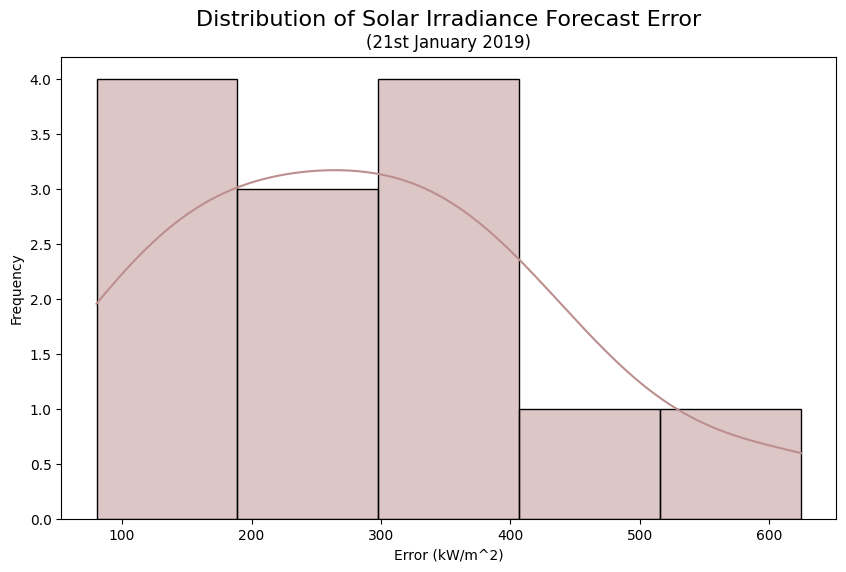

In [ ]:
# Solar distribution plots

# Create DataFrame
df = pd.DataFrame(Jan_solar_data)

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='error_solar', bins=5, kde=True, color = 'rosybrown')
plt.title('Distribution of Solar Irradiance Forecast Error\n', fontsize=16)  # Adding \n for a line break
plt.xlabel('Error (kW/m^2)')
plt.ylabel('Frequency')

# Add subtitle
plt.text(0.5, 1.02, '(21st January 2019)', ha='center', fontsize=12, transform=plt.gca().transAxes)

# Save the figure with high resolution
plt.savefig('Forecast Solar distribution (January 2019).png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# List to store each run of the code in the next code cell

compiled_solar_stats = []

In [ ]:
# Solar Data filtered

Jan_solar_data = Jan_filtered_I_2019['error_solar']


In [ ]:
# PDF fitting and testing for Solar irradiance data

# Dictionary to store goodness-of-fit statistics
solar_distribution_results = {}

# data
data = Jan_solar_data

# Distributions to consider
distribution_list = ['norm', 'rayleigh', 'loggamma', 'logistic', 'skewnorm', 'beta', 'gamma', 'cauchy', 'weibull_min']

# Iterate through distributions
for distribution in distribution_list:
    # Fit the data
    if distribution in ['norm', 'lognorm']:
        params = getattr(stats, distribution).fit(data)
        fitted_distribution = getattr(stats, distribution)(*params)
    else:
        params = getattr(stats, distribution).fit(data)
        fitted_distribution = getattr(stats, distribution)(*params[:-2], loc=params[-2], scale=params[-1])

    # Generate PDFs for the fitted distributions
    x = np.linspace(data.min(), data.max(), 100)
    pdf = fitted_distribution.pdf(x)

    # Perform goodness-of-fit tests
    ks_statistic, ks_p_value = stats.kstest(data, distribution, args=params)
    cvm_result_obj = stats.cramervonmises(data, fitted_distribution.cdf)

    # Extract statistic and p-value from CramerVonMisesResult object
    cvm_statistic, cvm_p_value = cvm_result_obj.statistic, cvm_result_obj.pvalue

    solar_distribution_results[distribution.capitalize()] = {'KS': [ks_statistic, ks_p_value], 'CvM': [cvm_statistic, cvm_p_value]}

# Display goodness-of-fit results
for distribution, results in solar_distribution_results.items():
    print(f'{distribution}: KS Statistic = {results["KS"][0]}, p-value = {results["KS"][1]}, CvM Statistic = {results["CvM"][0]}, p-value = {results["CvM"][1]}')

compiled_solar_stats.append(solar_distribution_results)

Norm: KS Statistic = 0.10118142184991269, p-value = 0.9973121739311179, CvM Statistic = 0.026402642248136564, p-value = 0.9894367386338971
Rayleigh: KS Statistic = 0.10967167858538222, p-value = 0.9926140848380871, CvM Statistic = 0.025412814470653557, p-value = 0.9913932713675376
Loggamma: KS Statistic = 0.10035906919602688, p-value = 0.997593855009387, CvM Statistic = 0.025945094199925682, p-value = 0.9903708188705037
Logistic: KS Statistic = 0.1077867287676495, p-value = 0.9939844861058721, CvM Statistic = 0.024246353423078223, p-value = 0.9933955897796435
Skewnorm: KS Statistic = 0.13465119204133214, p-value = 0.947542168593539, CvM Statistic = 0.029717294092044183, p-value = 0.981137747067431
Beta: KS Statistic = 0.2905918974413019, p-value = 0.18196813619932262, CvM Statistic = 0.3044768013903048, p-value = 0.13070932284189773
Gamma: KS Statistic = 0.14678378435672645, p-value = 0.9039936343148458, CvM Statistic = 0.036191984708851765, p-value = 0.9575863617416205
Cauchy: KS Stat

In [ ]:
# Checking the length of 'compiled_solar_stats'. The length should be 7.

print(len(compiled_solar_stats))

7


In [ ]:
# Convert list of dictionaries to DataFrame
# Set display options
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows

# Convert to DataFrame
df_a = pd.DataFrame(compiled_solar_stats)

# Write DataFrame to CSV
df_a.to_csv('compiled_solarerror_stats.csv', index=False)

* Result plotting for each PDF (KS test & CvM) for each year (2013 to 2019)

In [ ]:
# Import the csv file

compiled_stats_solar = pd.read_csv('compiled_solarerror_stats.csv')

In [ ]:
compiled_stats_solar

,Norm,Rayleigh,Loggamma,Logistic,Skewnorm,Beta,Gamma,Cauchy,Weibull_min
0,"{'KS': [0.2285819570378596, 0.3972249209226286...","{'KS': [0.27513432731793525, 0.198812247868924...","{'KS': [0.10285038767612215, 0.994804756423750...","{'KS': [0.1828743909856288, 0.6720960680038233...","{'KS': [0.1698525564791094, 0.7543309360365058...","{'KS': [0.2543719990279193, 0.2754160854815022...","{'KS': [0.23865006862521482, 0.346153249373669...","{'KS': [0.20101961659920858, 0.556699310091852...","{'KS': [0.15864780111690074, 0.820404364071464..."
1,"{'KS': [0.18991116863263935, 0.626940551307250...","{'KS': [0.21222921983146747, 0.488808555422133...","{'KS': [0.1750217542895406, 0.7221185211006296...","{'KS': [0.17009111527795984, 0.752862814691359...","{'KS': [0.17660975687142033, 0.712082309854504...","{'KS': [0.1234760562372239, 0.9654326864240859...","{'KS': [0.19589854595622402, 0.588812546134798...","{'KS': [0.23584104444248766, 0.359960276180933...","{'KS': [0.16771846881328423, 0.767369646331031..."
2,"{'KS': [0.2054195502346134, 0.5296153683961138...","{'KS': [0.24000416558349275, 0.339622515240908...","{'KS': [0.17631210646002127, 0.713967506002542...","{'KS': [0.17519758694810833, 0.721009974585038...","{'KS': [0.2388741049642935, 0.3450670965101823...","{'KS': [0.16095905378970887, 0.807314965173368...","{'KS': [0.21058876957548717, 0.498507306458305...","{'KS': [0.2588426141105533, 0.2573367631578103...","{'KS': [0.18483659761603588, 0.659501420287718..."
3,"{'KS': [0.15467725677641442, 0.868962330235250...","{'KS': [0.18808139342978947, 0.680608142421075...","{'KS': [0.15277862228804753, 0.877778960305107...","{'KS': [0.16365996551759368, 0.823737828074076...","{'KS': [0.15529068024847914, 0.866057382561119...","{'KS': [0.3742865517310413, 0.0382788748161220...","{'KS': [0.15483388919523716, 0.868223315227503...","{'KS': [0.18669906574505496, 0.689137553942457...","{'KS': [0.1848144402586439, 0.7007289728420745..."
4,"{'KS': [0.1665449306470702, 0.8081102009721526...","{'KS': [0.20366583159118756, 0.584381569690251...","{'KS': [0.10974979310007199, 0.992552613857962...","{'KS': [0.13849614135928645, 0.935275965525317...","{'KS': [0.1600251960988266, 0.8427043173307065...","{'KS': [0.09227837329135496, 0.999301891746700...","{'KS': [0.1737479300785928, 0.7672208855642774...","{'KS': [0.21062183153432357, 0.542409817487953...","{'KS': [0.15247584032710382, 0.879163553517710..."
5,"{'KS': [0.17778378647993398, 0.743372144859916...","{'KS': [0.19502666451656714, 0.637591746100284...","{'KS': [0.14696391652416785, 0.903245879431986...","{'KS': [0.1656932501313838, 0.8127731889245037...","{'KS': [0.1579447184260487, 0.8531643796103199...","{'KS': [0.1616780723820935, 0.8341846961965825...","{'KS': [0.1815538768338517, 0.7206446588925659...","{'KS': [0.19338433398014665, 0.647770089225339...","{'KS': [0.17117771041198726, 0.782086054319765..."
6,"{'KS': [0.10118142184991269, 0.997312173931117...","{'KS': [0.10967167858538222, 0.992614084838087...","{'KS': [0.10035906919602688, 0.997593855009387...","{'KS': [0.1077867287676495, 0.9939844861058721...","{'KS': [0.13465119204133214, 0.947542168593539...","{'KS': [0.2905918974413019, 0.1819681361993226...","{'KS': [0.14678378435672645, 0.903993634314845...","{'KS': [0.14794916581277834, 0.899109336440523...","{'KS': [0.13861379983154276, 0.934877278650688..."


In [ ]:
# Unpacking each cell to a wide format.
import ast

# Function to expand dictionary values into separate columns
def expand_dict_values(row, column_name):
    expanded_values = ast.literal_eval(row[column_name])
    for key, value in expanded_values.items():
        for i, v in enumerate(value):
            row[f"{column_name}_{key}_{i+1}"] = v
    return row

# Convert the dictionary to a DataFrame
df = pd.DataFrame(compiled_stats_solar)

# Iterate over each PDF column and expand values
for pdf in df.columns:
    df = df.apply(lambda row: expand_dict_values(row, pdf), axis=1)

# Drop the original PDF columns
df.drop(columns=list(compiled_stats_solar.keys()), inplace=True)

# Iterate over column names and replace '1' with 'stats' and '2' with 'pvalues'
df.columns = df.columns.str.replace('1', 'stats').str.replace('2', 'pvalues')

# Print the updated DataFrame
print(df)

   Norm_KS_stats  Norm_KS_pvalues  Norm_CvM_stats  Norm_CvM_pvalues  Rayleigh_KS_stats  Rayleigh_KS_pvalues  Rayleigh_CvM_stats  Rayleigh_CvM_pvalues  Loggamma_KS_stats  Loggamma_KS_pvalues  Loggamma_CvM_stats  Loggamma_CvM_pvalues  Logistic_KS_stats  Logistic_KS_pvalues  Logistic_CvM_stats  Logistic_CvM_pvalues  Skewnorm_KS_stats  Skewnorm_KS_pvalues  Skewnorm_CvM_stats  Skewnorm_CvM_pvalues  Beta_KS_stats  Beta_KS_pvalues  Beta_CvM_stats  Beta_CvM_pvalues  Gamma_KS_stats  Gamma_KS_pvalues  Gamma_CvM_stats  Gamma_CvM_pvalues  Cauchy_KS_stats  Cauchy_KS_pvalues  Cauchy_CvM_stats  Cauchy_CvM_pvalues  Weibull_min_KS_stats  Weibull_min_KS_pvalues  Weibull_min_CvM_stats  Weibull_min_CvM_pvalues
0       0.228582         0.397225        0.129899          0.461790           0.275134             0.198812            0.190189              0.289266           0.102850             0.994805            0.029861              0.980425           0.182874             0.672096            0.098047         

In [ ]:
# Filtering 'pvalues' columns only

pvalues_columns = [col for col in df.columns if 'pvalues' in col]

# Subset the DataFrame with the filtered column names
df_pvalues = df[pvalues_columns].copy()

# Create a range of datetime values from 2013 to 2019
years = ['2013', '2014', '2015', '2016', '2017', '2018', '2019']

# Add the 'Year' column to the DataFrame
df_pvalues.loc[:, 'Year'] = years

# Rearrange the columns so that 'Year' is the first column
df_pvalues = df_pvalues[['Year'] + [col for col in df_pvalues.columns if col != 'Year']]

# Print the subsetted DataFrame
print(df_pvalues)

   Year  Norm_KS_pvalues  Norm_CvM_pvalues  Rayleigh_KS_pvalues  Rayleigh_CvM_pvalues  Loggamma_KS_pvalues  Loggamma_CvM_pvalues  Logistic_KS_pvalues  Logistic_CvM_pvalues  Skewnorm_KS_pvalues  Skewnorm_CvM_pvalues  Beta_KS_pvalues  Beta_CvM_pvalues  Gamma_KS_pvalues  Gamma_CvM_pvalues  Cauchy_KS_pvalues  Cauchy_CvM_pvalues  Weibull_min_KS_pvalues  Weibull_min_CvM_pvalues
0  2013         0.397225          0.461790             0.198812              0.289266             0.994805              0.980425             0.672096              0.601174             0.754331              0.766313         0.275416          0.373982          0.346153           0.425348           0.556699            0.321416                0.820404                 0.715197
1  2014         0.626941          0.604517             0.488809              0.547724             0.722119              0.728785             0.752863              0.649384             0.712082              0.531498         0.965433          0.949662 

In [ ]:
import pandas as pd

# Reshape the DataFrame to long format
df_long = pd.melt(df_pvalues, id_vars='Year', var_name='PDF', value_name='Value')

# Extract PDF type and Stat type from 'PDF' column
df_long[['PDF', 'Pvalue']] = df_long['PDF'].str.rsplit('_', n=1, expand=True)

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_pvalues = df_long.pivot_table(index=['Year', 'PDF'], columns='Pvalue', values='Value').reset_index()

# Extract PDF type from 'PDF' column
df_pivot_pvalues['PDF_type'] = df_pivot_pvalues['PDF'].str.rsplit('_', n =1, expand=True)[0]

# Extracting CvM and KS values from 'PDF' column
df_pivot_pvalues['Test'] = df_pivot_pvalues['PDF'].str.split('_').str[-1]
df_pivot_pvalues['PDF'] = df_pivot_pvalues['PDF'].str.split('_').str[0]

# Pivoting the dataframe
df_pivot_pvalues = df_pivot_pvalues.pivot_table(index=['Year', 'PDF_type'], columns='Test', values='pvalues').reset_index()

# Renaming the columns
df_pivot_pvalues.columns.name = None  # Remove the name of columns
df_pivot_pvalues.rename(columns={'CvM': 'CvM_pvalues', 'KS': 'KS_pvalues'}, inplace=True)

print(df_pivot_pvalues)

    Year     PDF_type  CvM_pvalues  KS_pvalues
0   2013         Beta     0.373982    0.275416
1   2013       Cauchy     0.321416    0.556699
2   2013        Gamma     0.425348    0.346153
3   2013     Loggamma     0.980425    0.994805
4   2013     Logistic     0.601174    0.672096
..   ...          ...          ...         ...
58  2019     Logistic     0.993396    0.993984
59  2019         Norm     0.989437    0.997312
60  2019     Rayleigh     0.991393    0.992614
61  2019     Skewnorm     0.981138    0.947542
62  2019  Weibull_min     0.980392    0.934877

[63 rows x 4 columns]


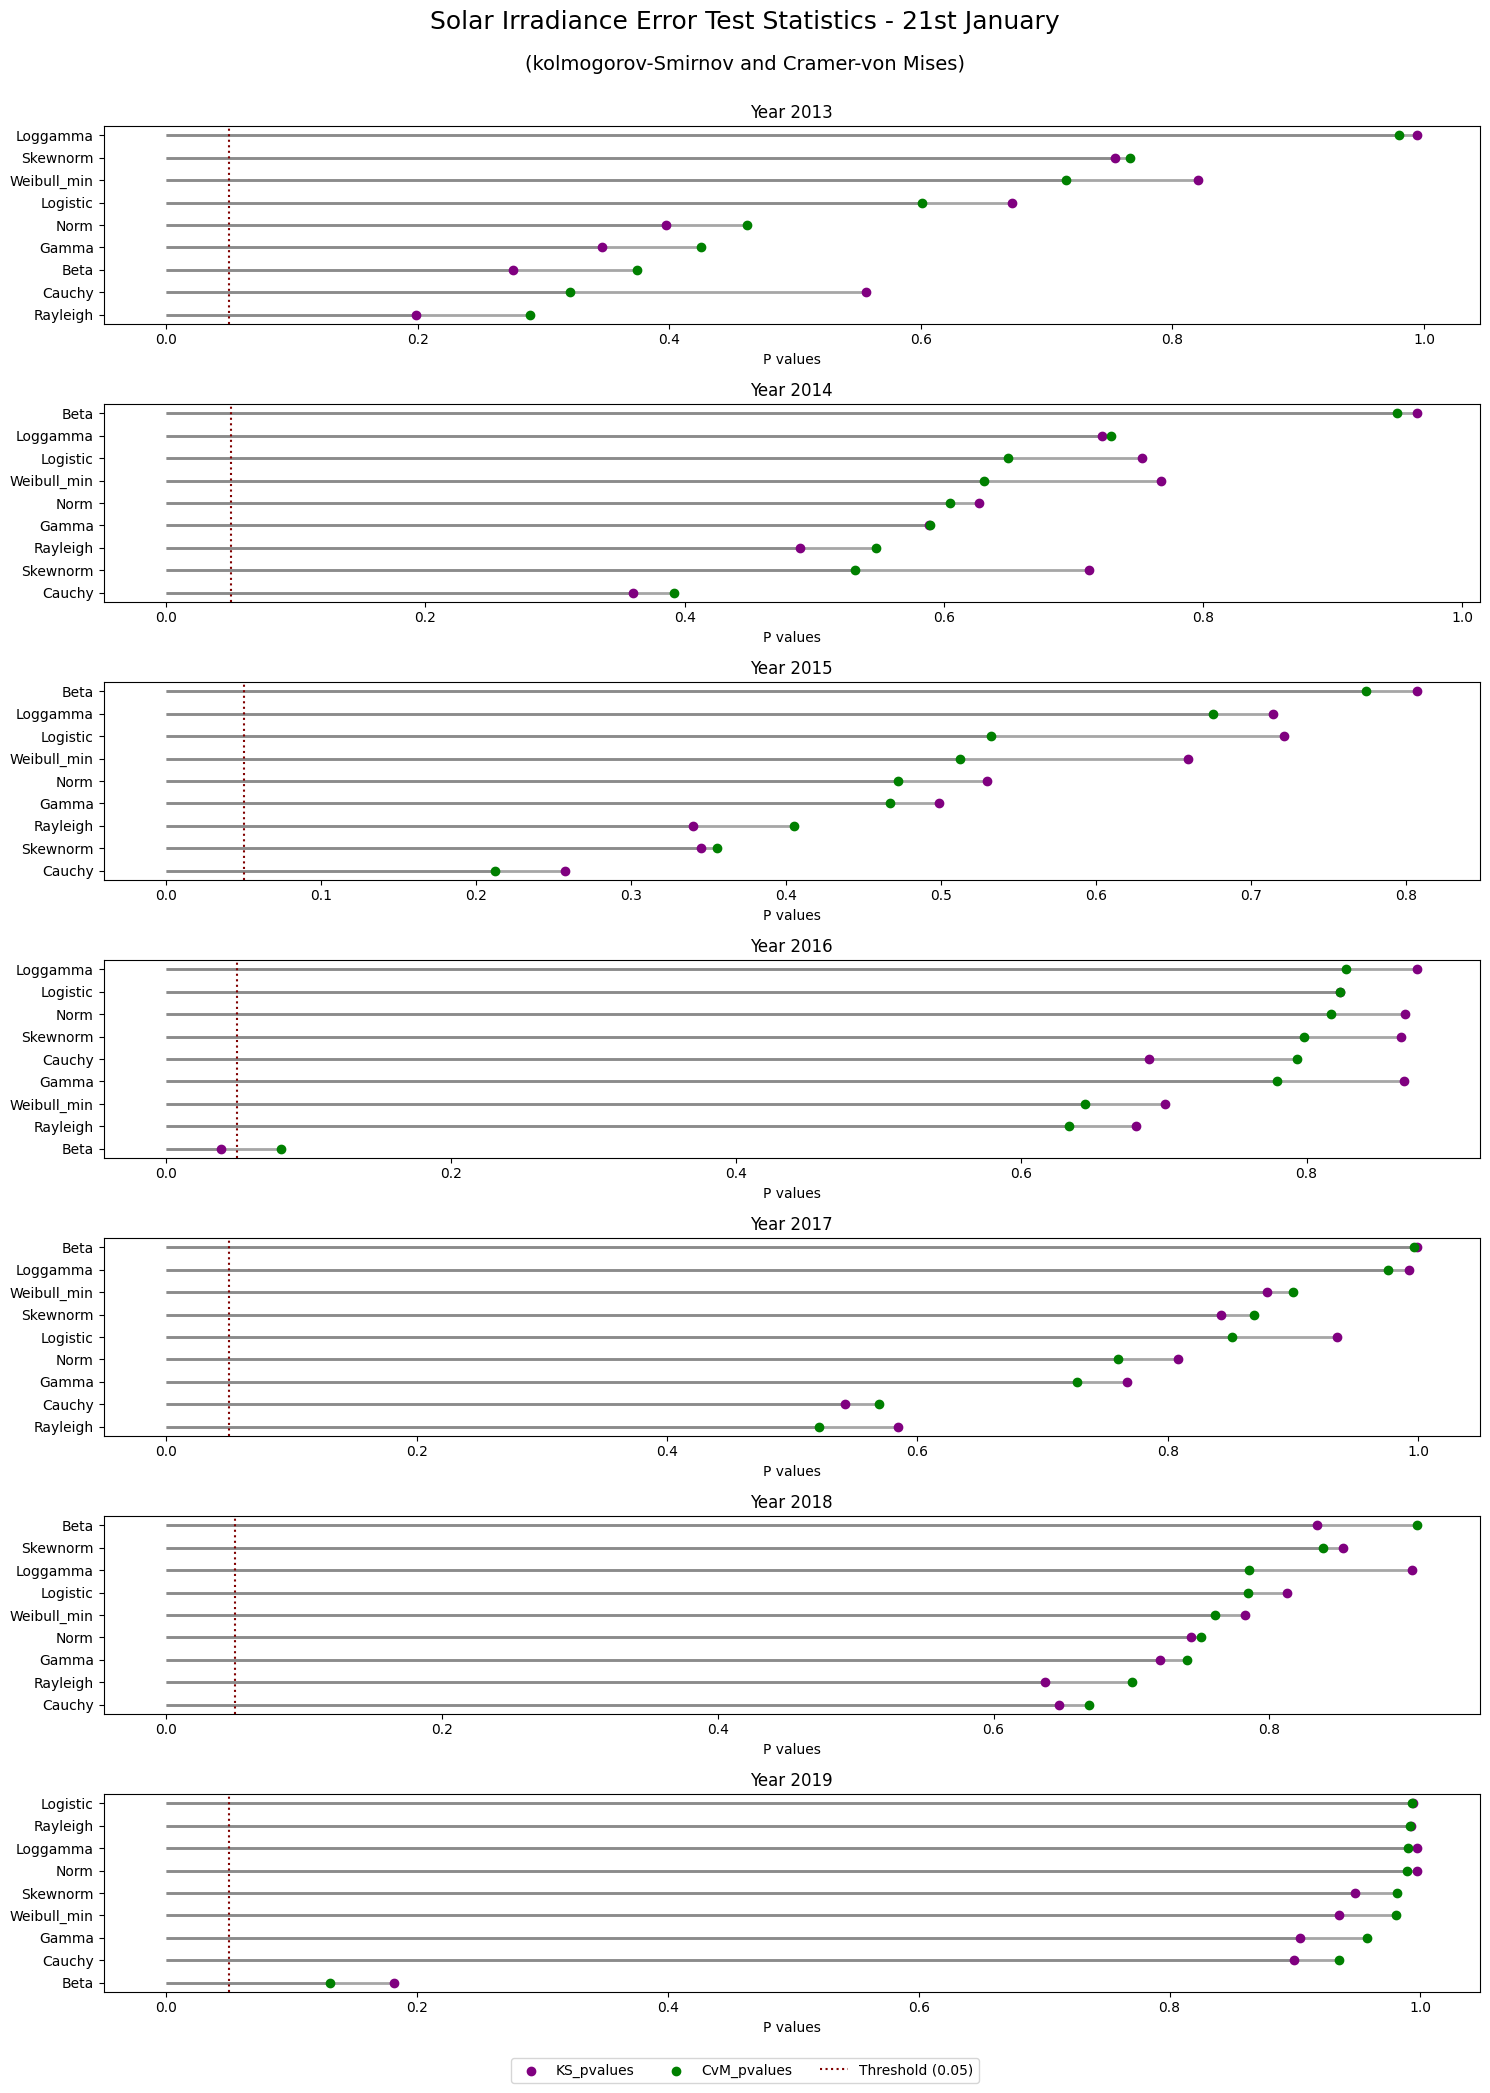

In [ ]:
# Plot of the 'Goodness of fit' for each PDF

# Convert data to DataFrame
df_1 = df_pivot_pvalues

# Sort DataFrame by 'KS_pvalues' and 'CvM_pvalues' in descending order
df_sorted = df_1.sort_values(by=['CvM_pvalues', 'KS_pvalues'], ascending=True)

# Create a lollipop plot
fig, axs = plt.subplots(7, 1, figsize=(15, 20))

# Iterate over each year
for i, year in enumerate(df_1['Year'].unique()):
    # Filter data for the current year
    year_data = df_sorted[df_sorted['Year'] == year]

    # Set up subplot
    ax = axs[i]

    # Plot the KS pvalues
    ax.scatter(year_data['KS_pvalues'], year_data['PDF_type'], color='purple', label='KS_pvalues', zorder=5)
    for _, row in year_data.iterrows():
        ax.hlines(row['PDF_type'], 0, row['KS_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Plot the CvM pvalues
    ax.scatter(year_data['CvM_pvalues'], year_data['PDF_type'], color='green', label='CvM_pvalues', zorder=5)
    for _, row in year_data.iterrows():
        ax.hlines(row['PDF_type'], 0, row['CvM_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Set labels and title
    ax.set_xlabel('P values')
    ax.set_ylabel('')
    ax.set_title(f'Year {year}')

    # Place a vertical dotted line at the value of 0.05
    ax.axvline(x=0.05, color='maroon', linestyle='dotted', label='Threshold (0.05)')

    # Disable legend
    ax.legend().remove()

# Add a title and subtitle to the figure
fig.suptitle('Solar Irradiance Error Test Statistics - 21st January', fontsize=18, y=1.02)
fig.text(0.5, 0.99, '(kolmogorov-Smirnov and Cramer-von Mises)', ha='center', fontsize=14)

# Add legend at the bottom
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)

# Adjust layout
plt.tight_layout()

# Save the figure with high resolution
plt.savefig('solarerror_test_stats(pvalues_2013_2019).png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Filtering for the 'stats' columns

stats_columns = [col for col in df.columns if 'stats' in col]

# Subset the DataFrame with the filtered column names
df_stats = df[stats_columns].copy()

# Create a range of datetime values from 2013 to 2019
years = ['2013', '2014', '2015', '2016', '2017', '2018', '2019']

# Add the 'Year' column to the DataFrame
df_stats.loc[:, 'Year'] = years

# Rearrange the columns so that 'Year' is the first column
df_stats = df_stats[['Year'] + [col for col in df_stats.columns if col != 'Year']]

df_stats = df_stats.rename(columns = {'Weibull_min_KS_stats': 'Weibull_KS_stats', 'Weibull_min_CvM_stats': 'Weibull_CvM_stats'})

# Print the subsetted DataFrame
print(df_stats)

   Year  Norm_KS_stats  Norm_CvM_stats  Rayleigh_KS_stats  Rayleigh_CvM_stats  Loggamma_KS_stats  Loggamma_CvM_stats  Logistic_KS_stats  Logistic_CvM_stats  Skewnorm_KS_stats  Skewnorm_CvM_stats  Beta_KS_stats  Beta_CvM_stats  Gamma_KS_stats  Gamma_CvM_stats  Cauchy_KS_stats  Cauchy_CvM_stats  Weibull_KS_stats  Weibull_CvM_stats
0  2013       0.228582        0.129899           0.275134            0.190189           0.102850            0.029861           0.182874            0.098047           0.169853            0.068911       0.254372        0.156401        0.238650         0.140102         0.201020          0.176121          0.158648           0.077332
1  2014       0.189911        0.097387           0.212229            0.109168           0.175022            0.075057           0.170091            0.088874           0.176610            0.112783       0.123476        0.037867        0.195899         0.100414         0.235841          0.150358          0.167718           0.092220
2  2015

In [ ]:
# Reshaping the stats column

# Reshape the DataFrame to long format
df_long = pd.melt(df_stats, id_vars='Year', var_name='PDF', value_name='Value')

# Extract PDF type and Stat type from 'PDF' column
df_long[['PDF', 'Stat', '_']] = df_long['PDF'].str.split('_', expand=True)

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_kstats = df_long.pivot_table(index=['Year', 'PDF'], columns='Stat', values='Value').reset_index()

# Rename the columns
df_pivot_kstats.columns.name = None
df_pivot_kstats.columns = ['Year', 'PDF', 'CvM_stats', 'KS_stats']

# Arrange PDFs in ascending order of KS_stats and CvM_stats for each year
df_pivot_kstats = df_pivot_kstats.groupby('Year').apply(lambda x: x.sort_values(by=['CvM_stats', 'KS_stats'])).reset_index(drop=True)

# Write to a csv file
df_pivot_kstats.to_csv('Error_Solar_KS_CvM_stats_2013-2019.csv')

print(df_pivot_kstats)

    Year       PDF  CvM_stats  KS_stats
0   2013  Loggamma   0.029861  0.102850
1   2013  Skewnorm   0.068911  0.169853
2   2013   Weibull   0.077332  0.158648
3   2013  Logistic   0.098047  0.182874
4   2013      Norm   0.129899  0.228582
..   ...       ...        ...       ...
58  2019  Skewnorm   0.029717  0.134651
59  2019   Weibull   0.029971  0.138614
60  2019     Gamma   0.036192  0.146784
61  2019    Cauchy   0.040962  0.147949
62  2019      Beta   0.304477  0.290592

[63 rows x 4 columns]


##### Part II

* Hourly Analysis (Solar Irradiance)

In [ ]:
# Select the Solar data for each hour

# Create a copy of the dataframe
Jan_data_solar = merged_error_solar_Jan.copy()

# Initialize an empty dictionary to store the load demand and price data for each hour (Jan)
hourly_data_Jan = {}

# Iterate through hours from 0 to 23
for hour in range(24):
    # Filter the data for the current hour and store it in the dictionary (The value of each key is a the Load demand)
    hourly_data_Jan[f'Hour_{hour}'] = Jan_data_solar[Jan_data_solar['hour'] == hour]['error_solar']

In [ ]:
hourly_data_Jan

{'Hour_0': Series([], Name: error_solar, dtype: float64),
 'Hour_1': Series([], Name: error_solar, dtype: float64),
 'Hour_2': Series([], Name: error_solar, dtype: float64),
 'Hour_3': Series([], Name: error_solar, dtype: float64),
 'Hour_4': Series([], Name: error_solar, dtype: float64),
 'Hour_5': Date
 2013-01-01 05:00:00    114.431946
 2013-01-02 05:00:00     66.340820
 2013-01-03 05:00:00     11.435760
 2013-01-04 05:00:00     34.842529
 2013-01-05 05:00:00     21.288303
                           ...    
 2019-01-03 05:00:00     33.342266
 2019-01-04 05:00:00     29.099052
 2019-01-05 05:00:00     32.912685
 2019-01-06 05:00:00     58.423073
 2019-01-07 05:00:00     56.852158
 Name: error_solar, Length: 119, dtype: float64,
 'Hour_6': Date
 2013-01-01 06:00:00     17.820526
 2013-01-02 06:00:00      9.606781
 2013-01-03 06:00:00     94.573761
 2013-01-04 06:00:00    117.166580
 2013-01-05 06:00:00    102.217987
                           ...    
 2019-01-27 06:00:00     30.274467

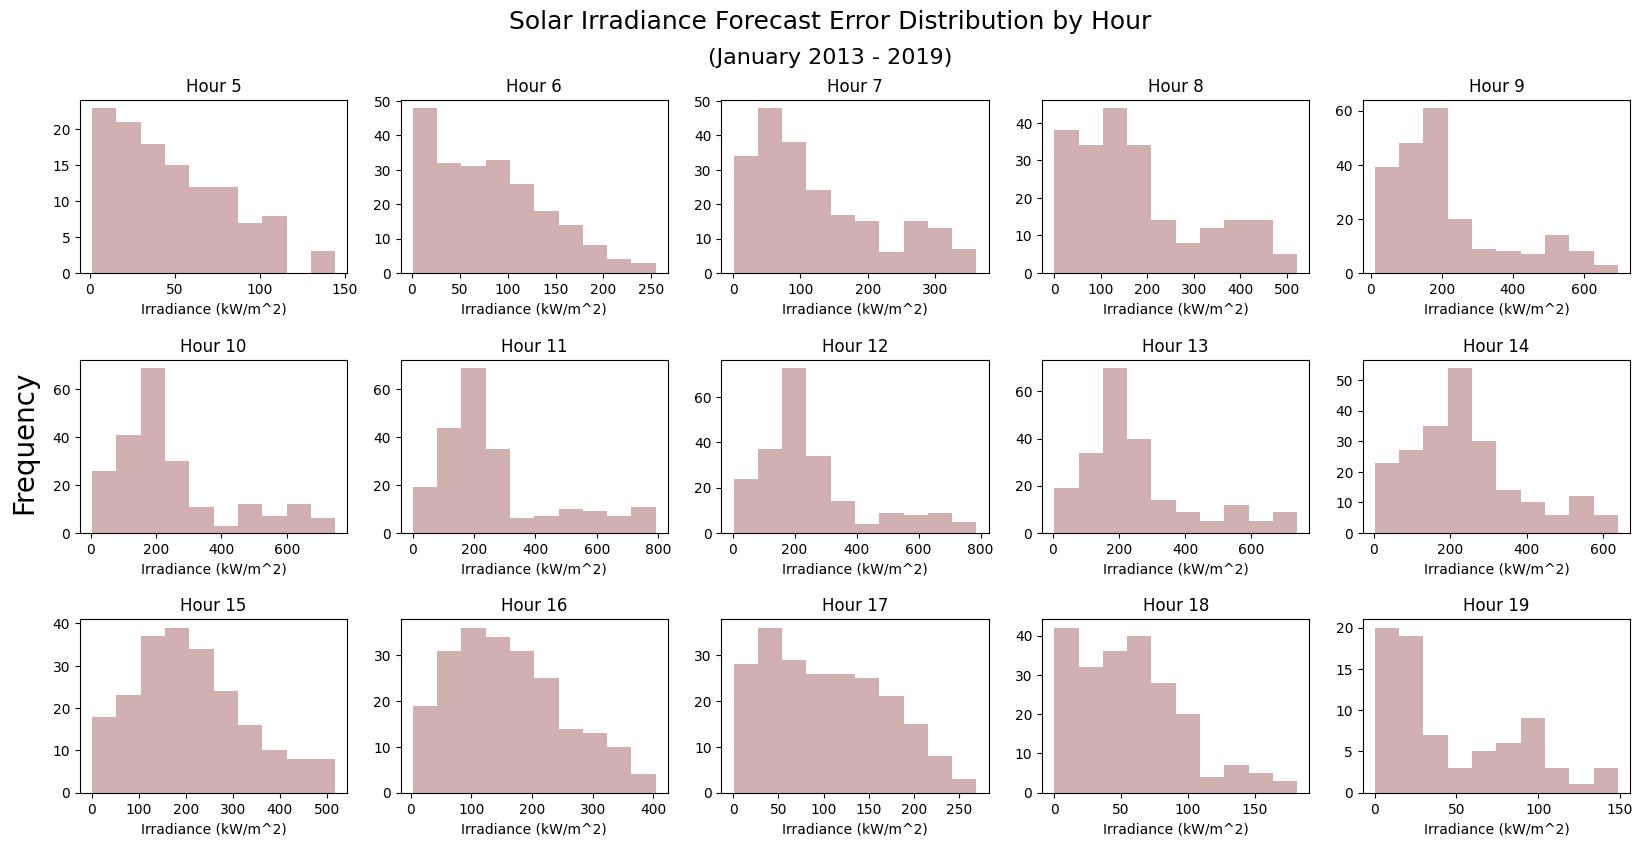

In [ ]:
# Plot type I (Histogram plot)

# Count the number of non-zero hours
non_zero_hours = [hour for hour in range(24) if hourly_data_Jan[f'Hour_{hour}'] is not None and any(hourly_data_Jan[f'Hour_{hour}'])]

# Calculate the number of rows and columns based on the number of non-zero hours
num_rows = 3
num_cols = 5

# Create the figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3))
fig.subplots_adjust(hspace=0.5)

# Iterate through the non-zero hours and create histograms
for idx, hour in enumerate(non_zero_hours):
    solar_data = hourly_data_Jan[f'Hour_{hour}']
    #solar_data = min_max_scaling(solar_data)
    ax = axes[idx // num_cols, idx % num_cols]
    ax.hist(solar_data, bins=10, color='rosybrown', alpha=0.7)
    ax.set_title(f'Hour {hour}')
    ax.set_xlabel('Irradiance (kW/m^2)')
    ax.set_ylabel('')

# Add a y-axis label to the overall figure
fig.text(0.09, 0.5, 'Frequency', va='center', rotation='vertical', fontsize=20)

# Add a title and subtitle to the figure
fig.suptitle('Solar Irradiance Forecast Error Distribution by Hour', fontsize=18, y=0.98)
fig.text(0.5, 0.92, '(January 2013 - 2019)', ha='center', fontsize=16)

# Save the figure with high resolution
plt.savefig('Hourly_solarerror_distribution.png', dpi=300, bbox_inches='tight')

# Show the histograms
plt.show()

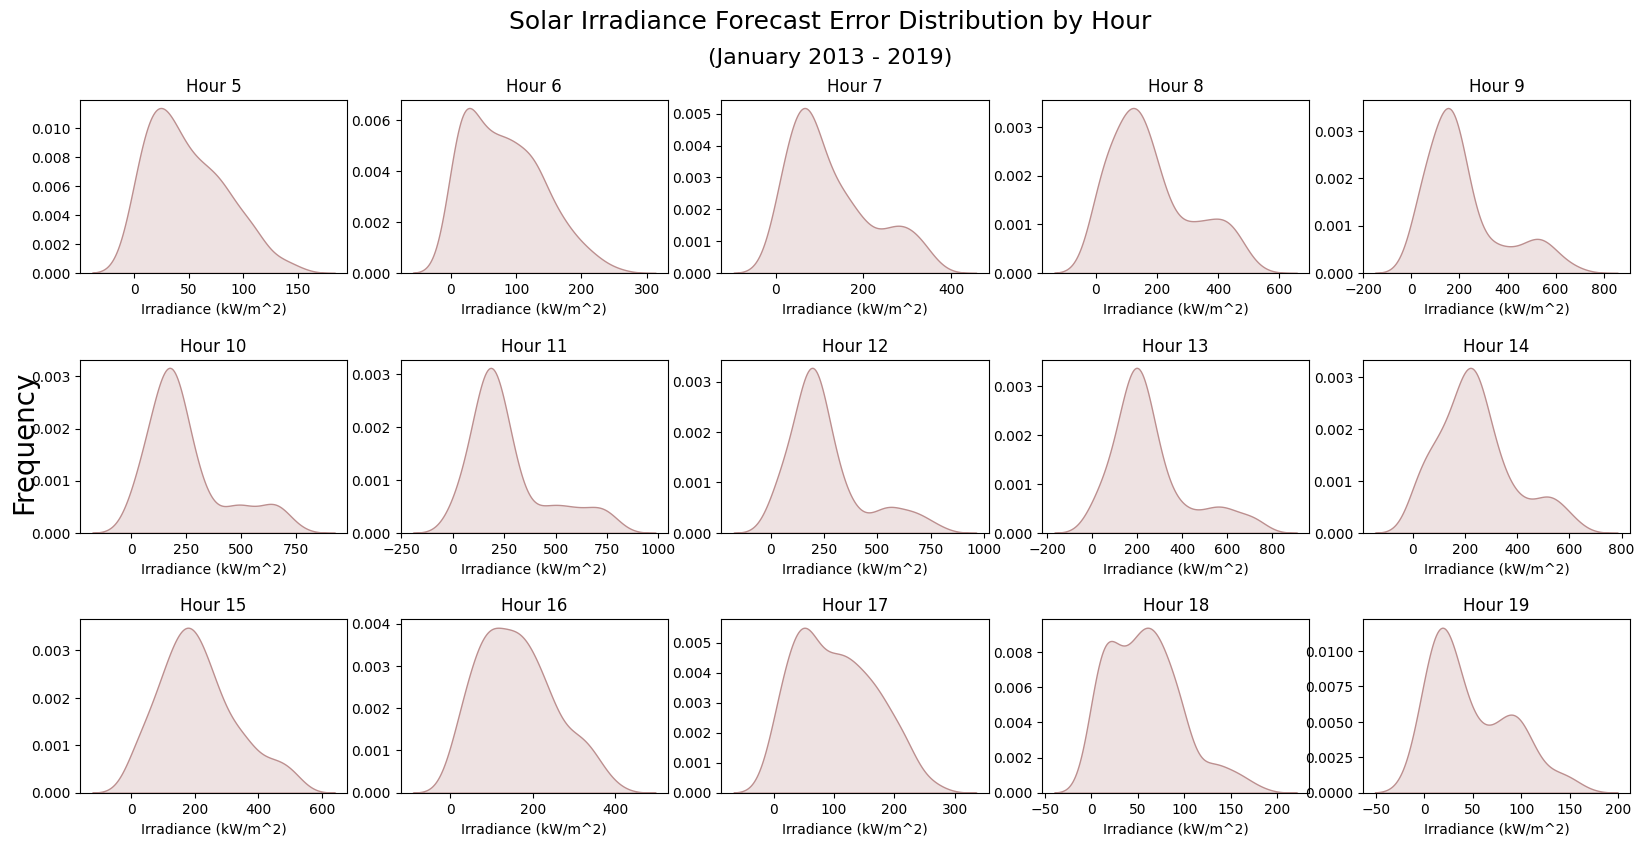

In [ ]:
# Plot type II (kernel density plot)

# Count the number of non-zero hours
non_zero_hours = [hour for hour in range(24) if hourly_data_Jan[f'Hour_{hour}'] is not None and any(hourly_data_Jan[f'Hour_{hour}'])]

# Calculate the number of rows and columns based on the number of non-zero hours
num_rows = 3
num_cols = 5

# Create the figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3))
fig.subplots_adjust(hspace=0.5)

# Iterate through the non-zero hours and create histograms
for idx, hour in enumerate(non_zero_hours):
    solar_data = hourly_data_Jan[f'Hour_{hour}']
    ax = axes[idx // num_cols, idx % num_cols]
    sns.kdeplot(solar_data, color='rosybrown', fill=True, ax=ax, legend = False)
    ax.set_title(f'Hour {hour}')
    ax.set_xlabel('Irradiance (kW/m^2)')
    ax.set_ylabel('')

# Add a y-axis label to the overall figure
fig.text(0.09, 0.5, 'Frequency', va='center', rotation='vertical', fontsize=20)

# Add a title and subtitle to the figure
fig.suptitle('Solar Irradiance Forecast Error Distribution by Hour', fontsize=18, y=0.98)
fig.text(0.5, 0.92, '(January 2013 - 2019)', ha='center', fontsize=16)

# Save the figure with high resolution
plt.savefig('Hourly_solarerror_distribution_density.png', dpi=300, bbox_inches='tight')

# Show the density plots
plt.show()

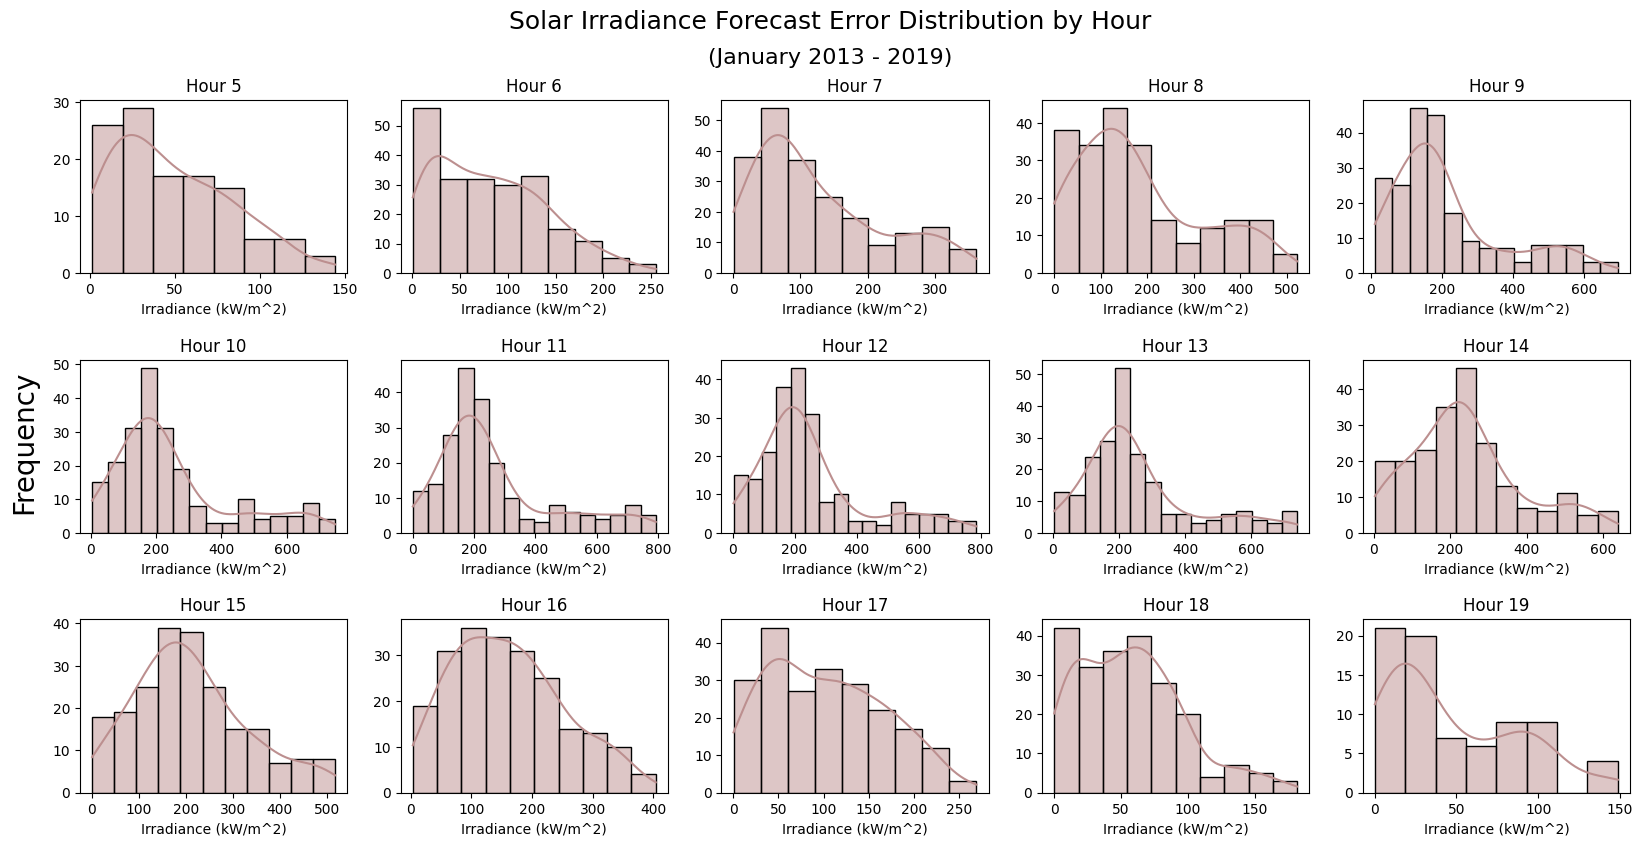

In [ ]:
# Plot type III (Histogram and kernel density plot)

# Count the number of non-zero hours
non_zero_hours = [hour for hour in range(24) if hourly_data_Jan[f'Hour_{hour}'] is not None and any(hourly_data_Jan[f'Hour_{hour}'])]

# Calculate the number of rows and columns based on the number of non-zero hours
num_rows = 3
num_cols = 5

# Create the figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3))
fig.subplots_adjust(hspace=0.5)

# Iterate through the non-zero hours and create histograms
for idx, hour in enumerate(non_zero_hours):
    solar_data = hourly_data_Jan[f'Hour_{hour}']
    ax = axes[idx // num_cols, idx % num_cols]
    sns.histplot(solar_data, kde=True, color='rosybrown', ax=ax, legend = False)
    ax.set_title(f'Hour {hour}')
    ax.set_xlabel('Irradiance (kW/m^2)')
    ax.set_ylabel('')
    ax.grid(False)

# Add a title and subtitle to the figure
fig.suptitle('Solar Irradiance Forecast Error Distribution by Hour', fontsize=18, y=0.98)
fig.text(0.5, 0.92, '(January 2013 - 2019)', ha='center', fontsize=16)

# Add a y-axis label to the overall figure
fig.text(0.09, 0.5, 'Frequency', va='center', rotation='vertical', fontsize=20)

# Save the figure with high resolution
plt.savefig('Hourly_solarerror_distribution_hist_and_density.png', dpi=300, bbox_inches='tight')

# Show the combined histogram and KDE plots
plt.show()

##### Goodness of fit (Solar Irradiance) - Testing for Weibull distribution alone

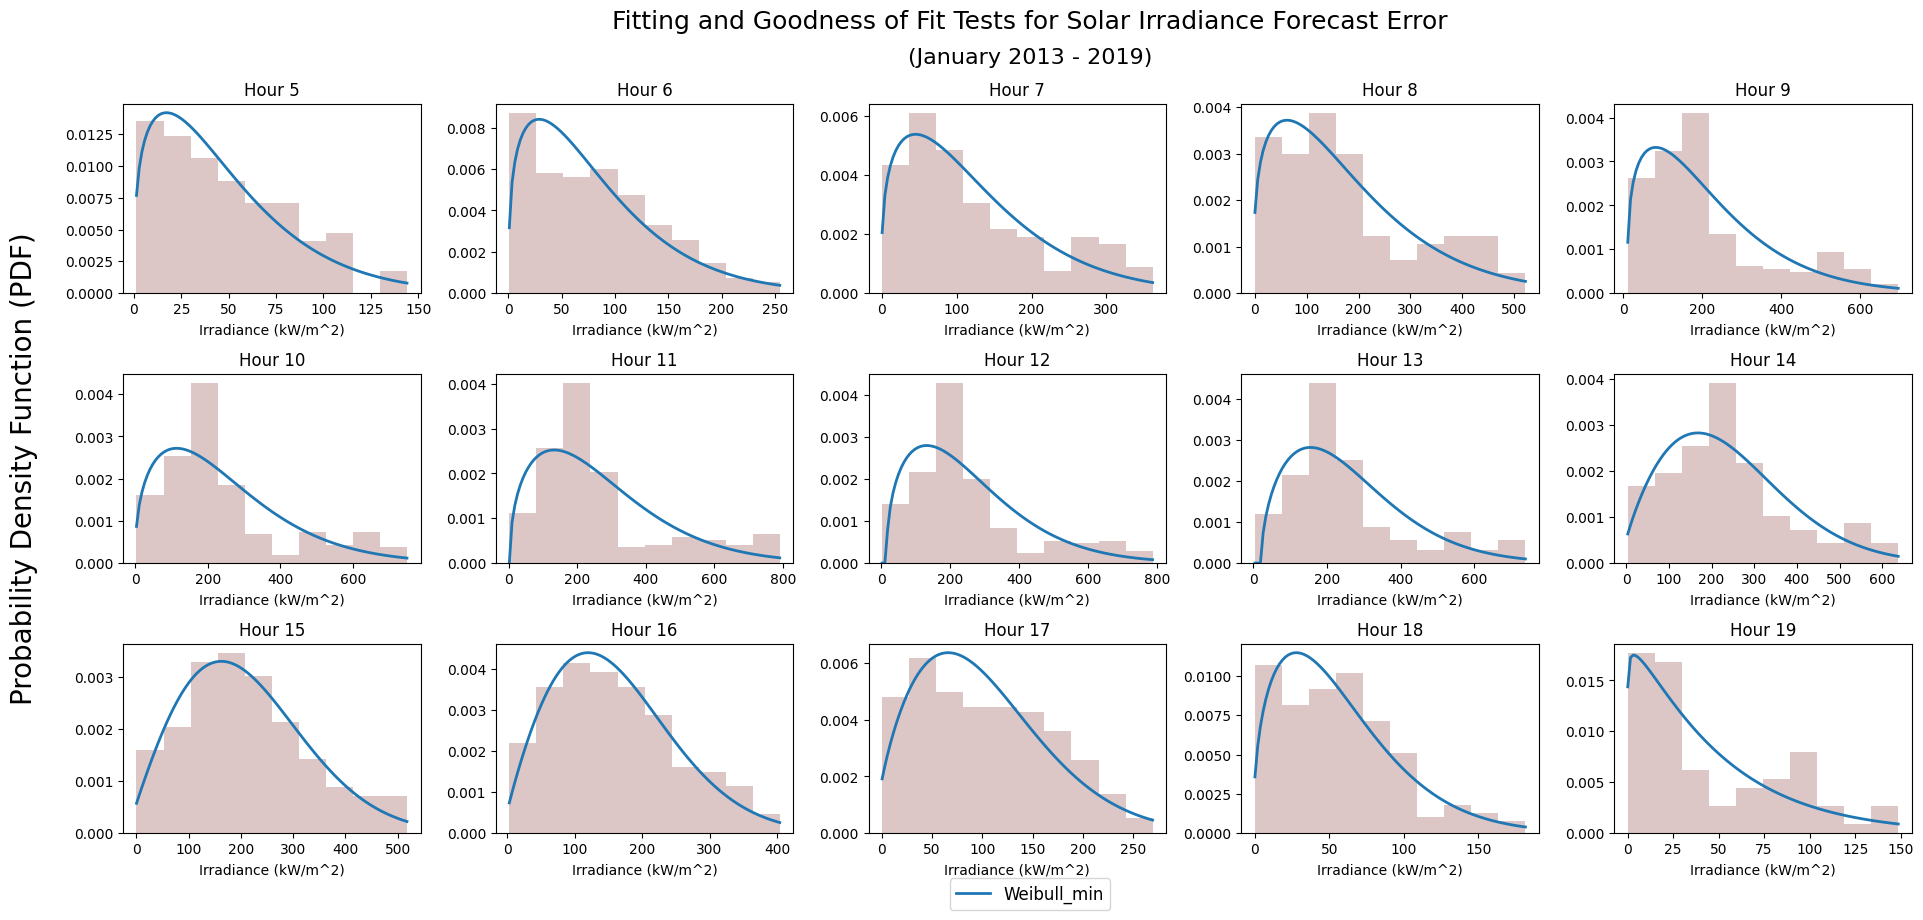

In [ ]:
# Count the number of non-zero hours
non_zero_hours = [hour for hour in range(24) if hourly_data_Jan[f'Hour_{hour}'] is not None and any(hourly_data_Jan[f'Hour_{hour}'])]

# Dictionary to store goodness-of-fit statistics for each hour
solar_distribution_results = {f'Hour_{hour}': {} for hour in non_zero_hours}

# New dictionary to store parameters of each PDF fitted at each hour
pdf_parameters = {f'Hour_{hour}': {} for hour in non_zero_hours}

# Distributions to consider
distribution_list = ['weibull_min']

# Calculate the number of rows and columns based on the number of non-zero hours
num_rows = 3
num_cols = 5

# Create the figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3))
fig.subplots_adjust(hspace=0.5)

# Iterate through the non-zero hours
for idx, hour in enumerate(non_zero_hours):
    # Extract the solar data for the current hour
    hour_data = hourly_data_Jan[f'Hour_{hour}']
    #hour_data = min_max_scaling(hour_data)
    # Dictionary to store parameters for this hour
    pdf_parameters_hour = {}

    # Iterate through distributions
    for distribution in distribution_list:
        # Fit the data
        if distribution in ['norm', 'lognorm', 'rayleigh']:
            params = getattr(stats, distribution).fit(hour_data)
            fitted_distribution = getattr(stats, distribution)(*params)
        else:
            params = getattr(stats, distribution).fit(hour_data)
            fitted_distribution = getattr(stats, distribution)(*params[:-2], loc=params[-2], scale=params[-1])

        # Store parameters
        pdf_parameters_hour[distribution] = params

        # Generate PDFs for the fitted distributions
        x = np.linspace(hour_data.min(), hour_data.max(), 100)
        pdf = fitted_distribution.pdf(x)

        # Perform goodness-of-fit tests
        ks_statistic, ks_p_value = stats.kstest(hour_data, distribution, args=params)
        cvm_result_obj = stats.cramervonmises(hour_data, fitted_distribution.cdf)

        # Extract statistic and p-value from CramerVonMisesResult object
        cvm_statistic, cvm_p_value = cvm_result_obj.statistic, cvm_result_obj.pvalue

        solar_distribution_results[f'Hour_{hour}'][distribution.capitalize()] = {'KS': [ks_statistic, ks_p_value], 'CvM': [cvm_statistic, cvm_p_value]}

        # Plot the histogram of the data and the fitted distribution
        ax = axes[idx // num_cols, idx % num_cols]
        ax.hist(hour_data, bins=10, density=True, alpha=0.5, color='rosybrown')
        ax.plot(x, pdf, label=distribution.capitalize(), linewidth=2.0)
        ax.set_title(f'Hour {hour}')
        ax.set_xlabel('Irradiance (kW/m^2)')
        ax.set_ylabel('')
        ax.grid(False)

    # Store parameters for this hour
    pdf_parameters[f'Hour_{hour}'] = pdf_parameters_hour

# Add a y-axis label to the overall figure
fig.text(-0.01, 0.5, 'Probability Density Function (PDF)', va='center', rotation='vertical', fontsize=20)

# Add a legend for the entire figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol=len(labels), fontsize=12)

# Add a title and subtitle to the figure
fig.suptitle('Fitting and Goodness of Fit Tests for Solar Irradiance Forecast Error', fontsize=18, y=1.01)
fig.text(0.5, 0.95, '(January 2013 - 2019)', ha='center', fontsize=16)

# Adjust the layout to make space for the overall legend
fig.tight_layout(rect=[0.01, 0.03, 0.95, 0.99])

# Save the figure with high resolution
plt.savefig('Error_Solar_Fitting_and_Goodness_of_Fit_Non_Zero_Hours.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
pdf_parameters

{'Hour_5': {'weibull_min': (1.3016533691425778,
   0.3051408790014226,
   51.83533530454126)},
 'Hour_6': {'weibull_min': (1.3017883030117456,
   0.4917816450569036,
   87.53441447179037)},
 'Hour_7': {'weibull_min': (1.3113645435726173,
   -0.5367841686373094,
   136.37949394592343)},
 'Hour_8': {'weibull_min': (1.3009959362589432,
   -2.347868673282101,
   197.7331432636173)},
 'Hour_9': {'weibull_min': (1.2996260039460692,
   10.943899955047613,
   221.5297461449976)},
 'Hour_10': {'weibull_min': (1.415468875864911,
   0.14245553342434747,
   270.99785780473326)},
 'Hour_11': {'weibull_min': (1.4451678699326203,
   2.3684865824792176,
   293.0267721905535)},
 'Hour_12': {'weibull_min': (1.4427957803474554,
   15.397719289345684,
   264.1563994390832)},
 'Hour_13': {'weibull_min': (1.5360657642059288,
   20.95962305087541,
   266.6723954333205)},
 'Hour_14': {'weibull_min': (1.7948190364403436,
   -12.456605649653117,
   283.93195854802616)},
 'Hour_15': {'weibull_min': (1.9789601780

In [ ]:
# Solar distribution results

# Convert to DataFrame
df_solar_jan = pd.DataFrame(solar_distribution_results).T

# Write DataFrame to CSV
df_solar_jan.to_csv('hourly_solarerror_distribution_results.csv')

In [ ]:
df_solar_jan = df_solar_jan.rename(columns = {'Weibull_min': 'Weibull'})
df_solar_jan

,Weibull
Hour_5,"{'KS': [0.05801853233209253, 0.796026024552377..."
Hour_6,"{'KS': [0.07320462955635043, 0.185880214507710..."
Hour_7,"{'KS': [0.058654217949986154, 0.42796757324116..."
Hour_8,"{'KS': [0.057738304882572256, 0.44783214338387..."
Hour_9,"{'KS': [0.09869761336499627, 0.027178008640638..."
Hour_10,"{'KS': [0.0967131419154652, 0.0322199095133390..."
Hour_11,"{'KS': [0.11408270579556345, 0.006459168615991..."
Hour_12,"{'KS': [0.1145665654566268, 0.0061529215571696..."
Hour_13,"{'KS': [0.10219157576931992, 0.019972672545057..."
Hour_14,"{'KS': [0.06478406047808899, 0.308801332863954..."


In [ ]:
import ast

# Convert list of dictionaries to DataFrame

# Function to expand dictionary values into separate columns
def expand_dict_values(row, column_name):
    expanded_values = row[column_name]

    for key, value in expanded_values.items():
        for i, v in enumerate(value):
            row[f"{column_name}_{key}_{i+1}"] = v
    return row

# Convert the dictionary to a DataFrame
df = pd.DataFrame(df_solar_jan)

# Iterate over each PDF column and expand values
for pdf in df.columns:
    df = df.apply(lambda row: expand_dict_values(row, pdf), axis=1)

# Drop the original PDF columns
df.drop(columns=list(df_solar_jan.keys()), inplace=True)

# Iterate over column names and replace '1' with 'stats' and '2' with 'pvalues'
df.columns = df.columns.str.replace('1', 'stats').str.replace('2', 'pvalues')

# Print the updated DataFrame
print(df)

         Weibull_KS_stats  Weibull_KS_pvalues  Weibull_CvM_stats  Weibull_CvM_pvalues
Hour_5           0.058019            0.796026           0.080409             0.690391
Hour_6           0.073205            0.185880           0.300545             0.134661
Hour_7           0.058654            0.427968           0.103400             0.568869
Hour_8           0.057738            0.447832           0.142966             0.411998
Hour_9           0.098698            0.027178           0.399140             0.072541
Hour_10          0.096713            0.032220           0.526305             0.034079
Hour_11          0.114083            0.006459           0.762061             0.008951
Hour_12          0.114567            0.006153           0.600741             0.022195
Hour_13          0.102192            0.019973           0.641581             0.017595
Hour_14          0.064784            0.308801           0.211716             0.245961
Hour_15          0.042023            0.822385         

In [ ]:
# Keep pvalues columns

pvalues_columns = [col for col in df.columns if 'pvalues' in col]

# Subset the DataFrame with the filtered column names
df_pvalues = df[pvalues_columns].copy()

# Create a range of datetime values from 2013 to 2019
hours = ['H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19']

# Add the 'Year' column to the DataFrame
df_pvalues.loc[:,'Hour'] = hours

# Rearrange the columns so that 'Year' is the first column
df_pvalues = df_pvalues[['Hour'] + [col for col in df_pvalues.columns if col != 'Hour']]

# Print the subsetted DataFrame
print(df_pvalues)

        Hour  Weibull_KS_pvalues  Weibull_CvM_pvalues
Hour_5    H5            0.796026             0.690391
Hour_6    H6            0.185880             0.134661
Hour_7    H7            0.427968             0.568869
Hour_8    H8            0.447832             0.411998
Hour_9    H9            0.027178             0.072541
Hour_10  H10            0.032220             0.034079
Hour_11  H11            0.006459             0.008951
Hour_12  H12            0.006153             0.022195
Hour_13  H13            0.019973             0.017595
Hour_14  H14            0.308801             0.245961
Hour_15  H15            0.822385             0.814256
Hour_16  H16            0.983099             0.973362
Hour_17  H17            0.454709             0.321559
Hour_18  H18            0.162270             0.182905
Hour_19  H19            0.231556             0.471585


In [ ]:
# Reshape the DataFrame to long format
df_long = pd.melt(df_pvalues, id_vars='Hour', var_name='PDF', value_name='Value')

# Convert 'Hour' column to categorical type to preserve order
df_long['Hour'] = pd.Categorical(df_long['Hour'], categories=['H{}'.format(i) for i in range(24)], ordered=True)

# Splitting the PDF column into two separate columns
pdf_split = df_long['PDF'].str.split('_', expand=True)

# Assigning the split columns to 'PDF' and 'Stat'
df_long['PDF'] = pdf_split[0]
df_long['Stat'] = pdf_split[1]

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_pvalues = df_long.pivot_table(index=['Hour', 'PDF'], columns='Stat', values='Value').reset_index()

# Rename the columns
df_pivot_pvalues.columns.name = None
df_pivot_pvalues.columns = ['Hour', 'PDF', 'CvM_pvalues', 'KS_pvalues']

print(df_pivot_pvalues)

   Hour      PDF  CvM_pvalues  KS_pvalues
0    H5  Weibull     0.690391    0.796026
1    H6  Weibull     0.134661    0.185880
2    H7  Weibull     0.568869    0.427968
3    H8  Weibull     0.411998    0.447832
4    H9  Weibull     0.072541    0.027178
5   H10  Weibull     0.034079    0.032220
6   H11  Weibull     0.008951    0.006459
7   H12  Weibull     0.022195    0.006153
8   H13  Weibull     0.017595    0.019973
9   H14  Weibull     0.245961    0.308801
10  H15  Weibull     0.814256    0.822385
11  H16  Weibull     0.973362    0.983099
12  H17  Weibull     0.321559    0.454709
13  H18  Weibull     0.182905    0.162270
14  H19  Weibull     0.471585    0.231556


In [ ]:
df_pivot_pvalues.loc[df_pivot_pvalues['Hour'] == 'H12']

,Hour,PDF,CvM_pvalues,KS_pvalues
7,H12,Weibull,0.022195,0.006153


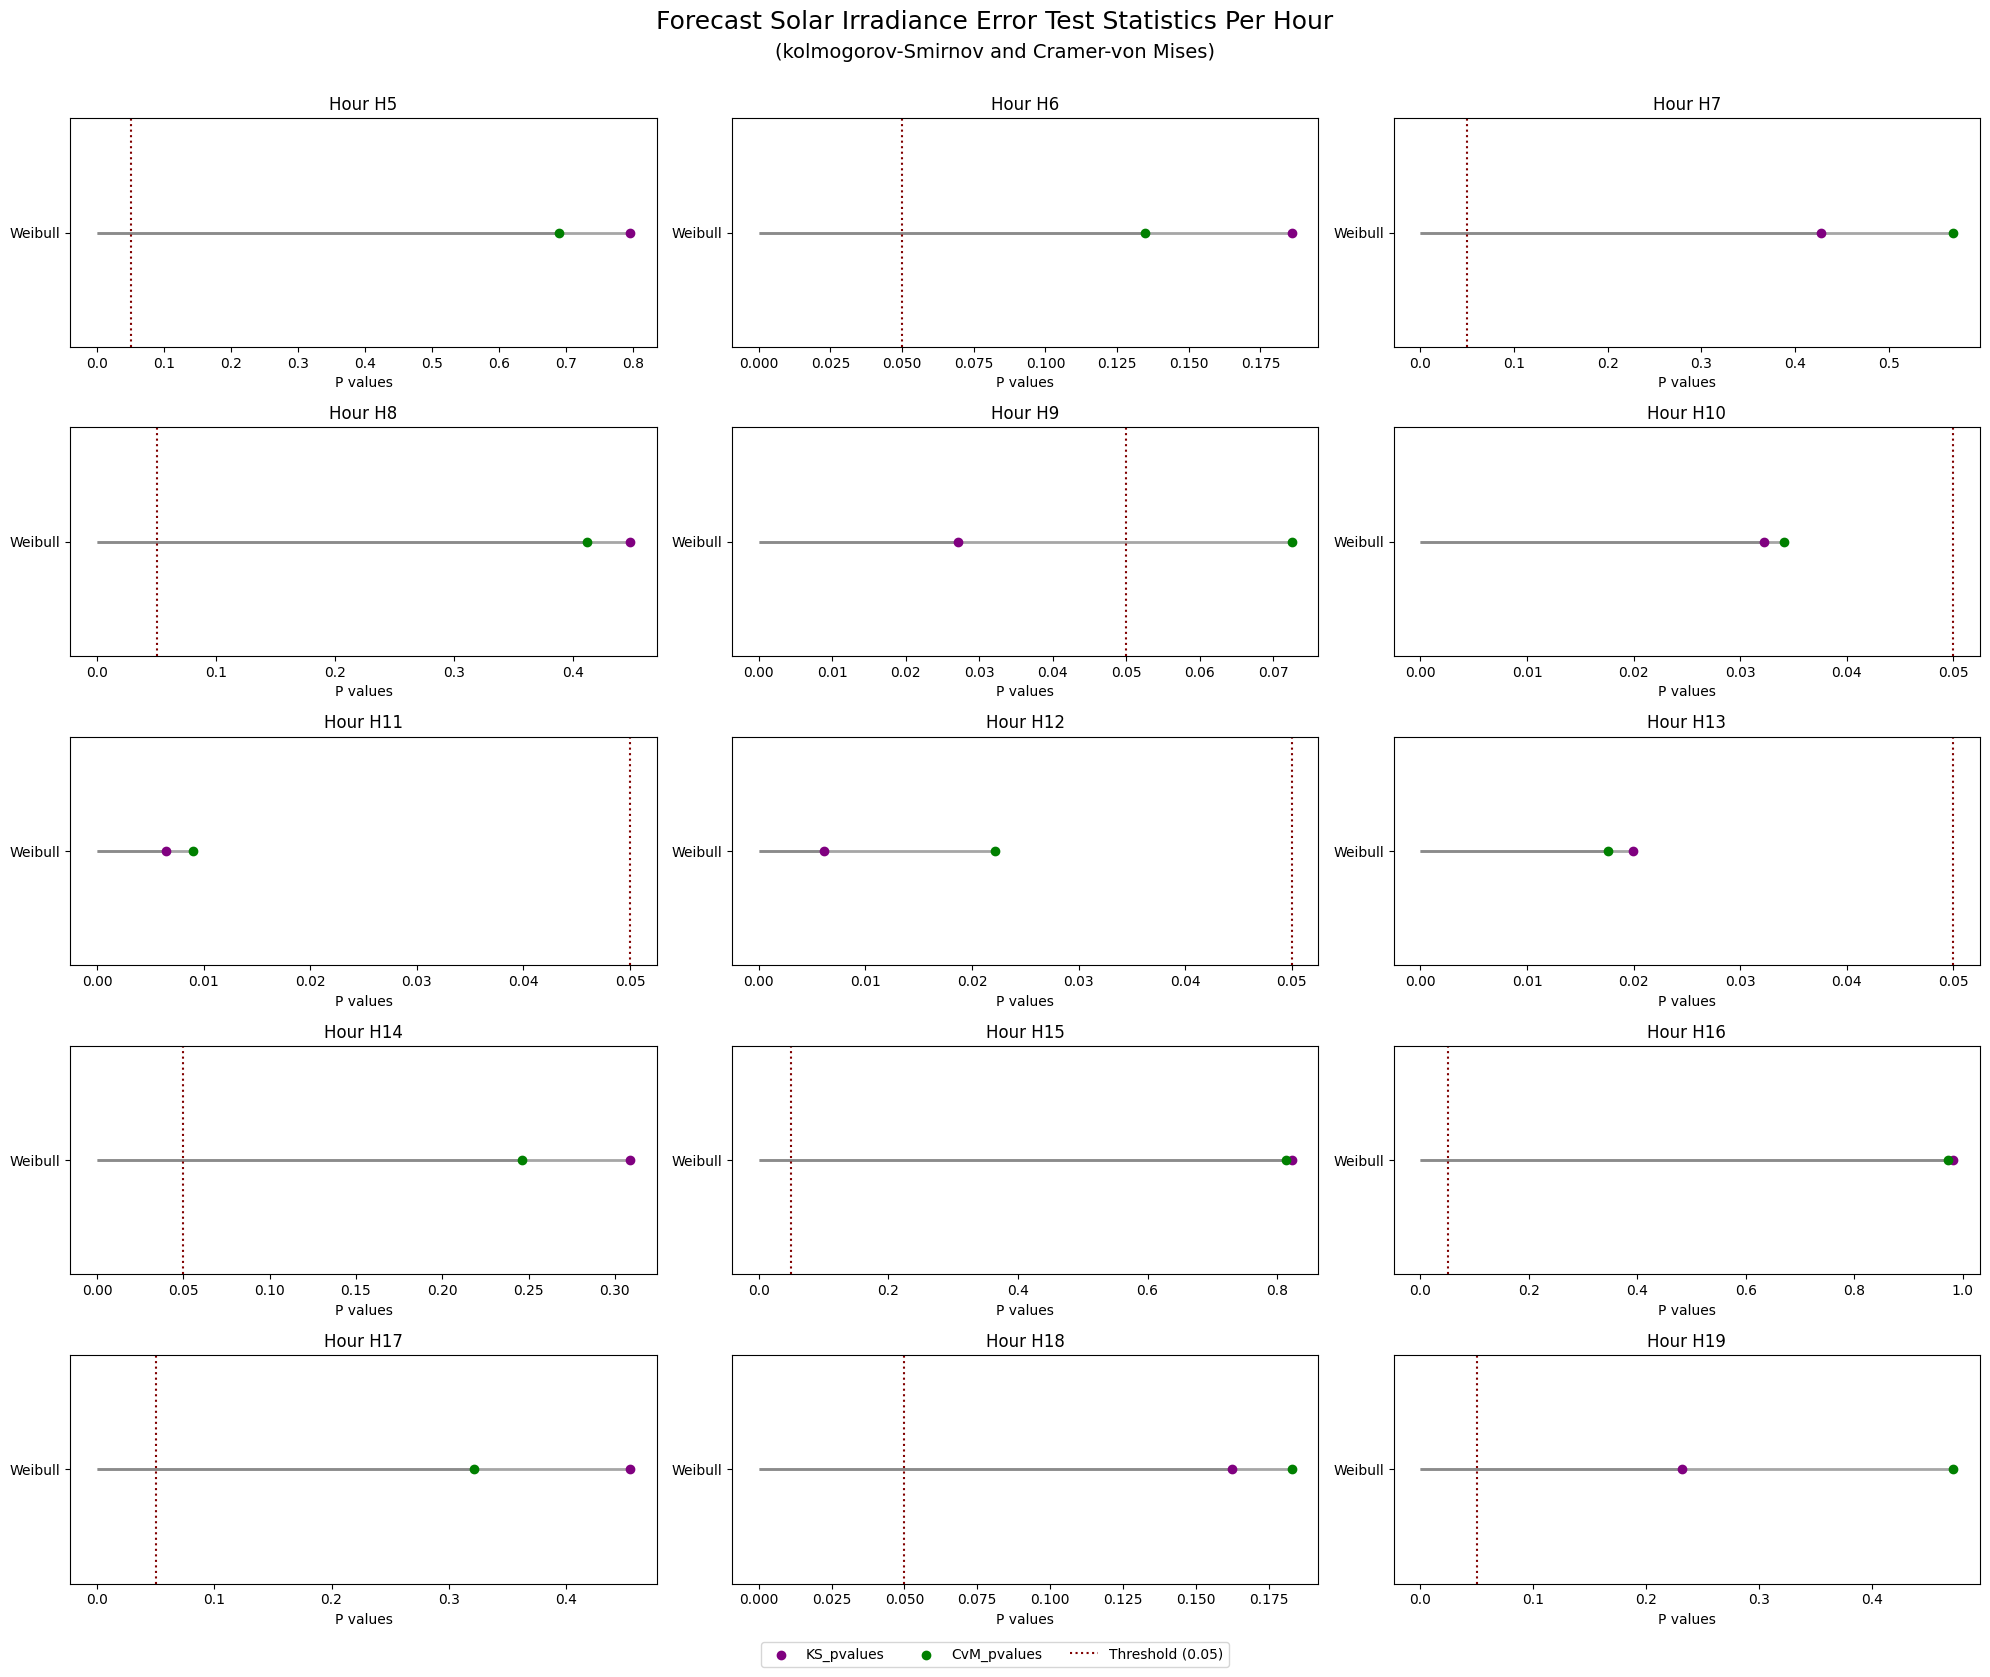

In [ ]:
# Convert data to DataFrame
df_1 = df_pivot_pvalues

# Sort DataFrame by 'KS_pvalues' and 'CvM_pvalues' in descending order
df_sorted = df_1.sort_values(by=['CvM_pvalues', 'KS_pvalues'], ascending=True)

# Create a lollipop plot
fig, axs = plt.subplots(5, 3, figsize=(20, 16))
fig.subplots_adjust(hspace=0.5)

# Flatten the axs array
axs_flat = axs.flat

# Iterate over each Hour
for i, hour in enumerate(df_1['Hour'].unique()):
    # Filter data for the current hour
    hour_data = df_sorted[df_sorted['Hour'] == hour]

    # Set up subplot
    ax = next(axs_flat)

    # Plot the KS pvalues
    ax.scatter(hour_data['KS_pvalues'], hour_data['PDF'], color='purple', label='KS_pvalues', zorder=5)
    for _, row in hour_data.iterrows():
        ax.hlines(row['PDF'], 0, row['KS_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Plot the CvM pvalues
    ax.scatter(hour_data['CvM_pvalues'], hour_data['PDF'], color='green', label='CvM_pvalues', zorder=5)
    for _, row in hour_data.iterrows():
        ax.hlines(row['PDF'], 0, row['CvM_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Set labels and title
    ax.set_xlabel('P values')
    ax.set_ylabel('')
    ax.set_title(f'Hour {hour}')

    # Place a vertical dotted line at the value of 0.05
    ax.axvline(x=0.05, color='maroon', linestyle='dotted', label='Threshold (0.05)')

    # Disable legend
    ax.legend().remove()

# Add a title and subtitle to the figure
fig.suptitle('Forecast Solar Irradiance Error Test Statistics Per Hour', fontsize=18, y=1.02)
fig.text(0.5, 0.99, '(kolmogorov-Smirnov and Cramer-von Mises)', ha='center', fontsize=14)

# Add legend at the bottom
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)

# Adjust layout
plt.tight_layout()

# Save the figure with high resolution
plt.savefig('Solarerror_test_stats_per_hour.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Filtering and processing the 'stats' columns

stats_columns = [col for col in df.columns if 'stats' in col]

# Subset the DataFrame with the filtered column names
df_stats = df[stats_columns].copy()

# Create a range of datetime values from Hour 0 to Hour 23
hours = ['H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19']

# Add the 'Hour' column to the DataFrame
df_stats.loc[:,'Hour'] = hours

# Rearrange the columns so that 'Year' is the first column
df_stats = df_stats[['Hour'] + [col for col in df_stats.columns if col != 'Hour']]

# Print the subsetted DataFrame
print(df_stats)

        Hour  Weibull_KS_stats  Weibull_CvM_stats
Hour_5    H5          0.058019           0.080409
Hour_6    H6          0.073205           0.300545
Hour_7    H7          0.058654           0.103400
Hour_8    H8          0.057738           0.142966
Hour_9    H9          0.098698           0.399140
Hour_10  H10          0.096713           0.526305
Hour_11  H11          0.114083           0.762061
Hour_12  H12          0.114567           0.600741
Hour_13  H13          0.102192           0.641581
Hour_14  H14          0.064784           0.211716
Hour_15  H15          0.042023           0.060039
Hour_16  H16          0.030664           0.030906
Hour_17  H17          0.057426           0.175097
Hour_18  H18          0.075292           0.254349
Hour_19  H19          0.116874           0.126280


In [ ]:
# Reshaping the stats column

import pandas as pd

# Reshape the DataFrame to long format
df_long = pd.melt(df_stats, id_vars='Hour', var_name='PDF', value_name='Value')

# Convert 'Hour' column to categorical type to preserve order
df_long['Hour'] = pd.Categorical(df_long['Hour'], categories=['H{}'.format(i) for i in range(24)], ordered=True)

# Splitting the PDF column into two separate columns
pdf_split = df_long['PDF'].str.split('_', expand=True)

# Assigning the split columns to 'PDF' and 'Stat'
df_long['PDF'] = pdf_split[0]
df_long['Stat'] = pdf_split[1]

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_kstats = df_long.pivot_table(index=['Hour', 'PDF'], columns='Stat', values='Value').reset_index()

# Rename the columns
df_pivot_kstats.columns.name = None
df_pivot_kstats.columns = ['Hour', 'PDF', 'CvM_stats', 'KS_stats']

# Arrange PDFs in ascending order of KS_stats and CvM_stats for each year
df_pivot_kstats = df_pivot_kstats.groupby('Hour').apply(lambda x: x.sort_values(by=['CvM_stats', 'KS_stats'])).reset_index(drop=True)

# Write to a csv file
df_pivot_kstats.to_csv('Solarerror_KS_CvM_stats_All_hours.csv')

print(df_pivot_kstats)

   Hour      PDF  CvM_stats  KS_stats
0    H5  Weibull   0.080409  0.058019
1    H6  Weibull   0.300545  0.073205
2    H7  Weibull   0.103400  0.058654
3    H8  Weibull   0.142966  0.057738
4    H9  Weibull   0.399140  0.098698
5   H10  Weibull   0.526305  0.096713
6   H11  Weibull   0.762061  0.114083
7   H12  Weibull   0.600741  0.114567
8   H13  Weibull   0.641581  0.102192
9   H14  Weibull   0.211716  0.064784
10  H15  Weibull   0.060039  0.042023
11  H16  Weibull   0.030906  0.030664
12  H17  Weibull   0.175097  0.057426
13  H18  Weibull   0.254349  0.075292
14  H19  Weibull   0.126280  0.116874


<ipython-input-18-be649853ecc7>:26: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df_pivot_kstats = df_pivot_kstats.groupby('Hour').apply(lambda x: x.sort_values(by=['CvM_stats', 'KS_stats'])).reset_index(drop=True)


In [ ]:
# PDF parameters for each fitted PDF

pdf_parameters

{'Hour_5': {'weibull_min': (1.3016533691425778,
   0.3051408790014226,
   51.83533530454126)},
 'Hour_6': {'weibull_min': (1.3017883030117456,
   0.4917816450569036,
   87.53441447179037)},
 'Hour_7': {'weibull_min': (1.3113645435726173,
   -0.5367841686373094,
   136.37949394592343)},
 'Hour_8': {'weibull_min': (1.3009959362589432,
   -2.347868673282101,
   197.7331432636173)},
 'Hour_9': {'weibull_min': (1.2996260039460692,
   10.943899955047613,
   221.5297461449976)},
 'Hour_10': {'weibull_min': (1.415468875864911,
   0.14245553342434747,
   270.99785780473326)},
 'Hour_11': {'weibull_min': (1.4451678699326203,
   2.3684865824792176,
   293.0267721905535)},
 'Hour_12': {'weibull_min': (1.4427957803474554,
   15.397719289345684,
   264.1563994390832)},
 'Hour_13': {'weibull_min': (1.5360657642059288,
   20.95962305087541,
   266.6723954333205)},
 'Hour_14': {'weibull_min': (1.7948190364403436,
   -12.456605649653117,
   283.93195854802616)},
 'Hour_15': {'weibull_min': (1.9789601780

In [ ]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

pdf_df = pd.DataFrame(pdf_parameters).T
pdf_df

,weibull_min
Hour_5,"(1.3016533691425778, 0.3051408790014226, 51.83..."
Hour_6,"(1.3017883030117456, 0.4917816450569036, 87.53..."
Hour_7,"(1.3113645435726173, -0.5367841686373094, 136...."
Hour_8,"(1.3009959362589432, -2.347868673282101, 197.7..."
Hour_9,"(1.2996260039460692, 10.943899955047613, 221.5..."
Hour_10,"(1.415468875864911, 0.14245553342434747, 270.9..."
Hour_11,"(1.4451678699326203, 2.3684865824792176, 293.0..."
Hour_12,"(1.4427957803474554, 15.397719289345684, 264.1..."
Hour_13,"(1.5360657642059288, 20.95962305087541, 266.67..."
Hour_14,"(1.7948190364403436, -12.456605649653117, 283...."


In [ ]:
# Unpacking PDF parameters to a 'wider' format

# Dataframe
df = pdf_df.copy()

# New DataFrame to store transformed data
new_pdf_df = pd.DataFrame()

# Function to split column based on length of content
def split_columns(hour_data, pdf_name):
    new_columns = {}
    if len(hour_data) == 2:
        new_columns[f'{pdf_name}_loc'] = hour_data[0]
        new_columns[f'{pdf_name}_scale'] = hour_data[1]
    elif len(hour_data) == 3:
        new_columns[f'{pdf_name}_shape'] = hour_data[0]
        new_columns[f'{pdf_name}_loc'] = hour_data[1]
        new_columns[f'{pdf_name}_scale'] = hour_data[2]
    elif len(hour_data) == 4:
        new_columns[f'{pdf_name}_shape1'] = hour_data[0]
        new_columns[f'{pdf_name}_shape2'] = hour_data[1]
        new_columns[f'{pdf_name}_loc'] = hour_data[2]
        new_columns[f'{pdf_name}_scale'] = hour_data[3]
    else:
        raise ValueError(f"Invalid length of content: {len(hour_data)}")
    return new_columns

# Iterate over each hour's data
for hour in range(5,20):
    hour_data = df.loc[f'Hour_{hour}']

    # Process each column
    for column in hour_data.index:
        pdf_name = column
        new_columns = split_columns(hour_data[column], pdf_name)

        # Add new columns to the new dataframe
        for new_column_name, new_column_data in new_columns.items():
            new_pdf_df.loc[f'Hour_{hour}', new_column_name] = new_column_data

In [ ]:
new_pdf_df

,weibull_min_shape,weibull_min_loc,weibull_min_scale
Hour_5,1.301653,0.305141,51.835335
Hour_6,1.301788,0.491782,87.534414
Hour_7,1.311365,-0.536784,136.379494
Hour_8,1.300996,-2.347869,197.733143
Hour_9,1.299626,10.943900,221.529746
Hour_10,1.415469,0.142456,270.997858
Hour_11,1.445168,2.368487,293.026772
Hour_12,1.442796,15.397719,264.156399
Hour_13,1.536066,20.959623,266.672395
Hour_14,1.794819,-12.456606,283.931959


In [ ]:
# Create a range of datetime values from 2013 to 2019
hours = ['H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19']

# Add the 'Year' column to the DataFrame
new_pdf_df['Hour'] = hours

# Rearrange the columns so that 'Year' is the first column
new_pdf_df = new_pdf_df[['Hour'] + [col for col in new_pdf_df.columns if col != 'Hour']]

# Print the subsetted DataFrame
print(new_pdf_df)

        Hour  weibull_min_shape  weibull_min_loc  weibull_min_scale
Hour_5    H5           1.301653         0.305141          51.835335
Hour_6    H6           1.301788         0.491782          87.534414
Hour_7    H7           1.311365        -0.536784         136.379494
Hour_8    H8           1.300996        -2.347869         197.733143
Hour_9    H9           1.299626        10.943900         221.529746
Hour_10  H10           1.415469         0.142456         270.997858
Hour_11  H11           1.445168         2.368487         293.026772
Hour_12  H12           1.442796        15.397719         264.156399
Hour_13  H13           1.536066        20.959623         266.672395
Hour_14  H14           1.794819       -12.456606         283.931959
Hour_15  H15           1.978960       -17.832656         257.481163
Hour_16  H16           1.892728        -6.804121         188.655689
Hour_17  H17           1.703640        -7.198161         122.917968
Hour_18  H18           1.452102        -1.001909

* Process of obtaining the parameters of the **best** PDF for each hour

In [ ]:
df_pivot_pvalues

,Hour,PDF,CvM_pvalues,KS_pvalues
0,H5,Weibull,0.690391,0.796026
1,H6,Weibull,0.134661,0.185880
2,H7,Weibull,0.568869,0.427968
3,H8,Weibull,0.411998,0.447832
4,H9,Weibull,0.072541,0.027178
5,H10,Weibull,0.034079,0.032220
6,H11,Weibull,0.008951,0.006459
7,H12,Weibull,0.022195,0.006153
8,H13,Weibull,0.017595,0.019973
9,H14,Weibull,0.245961,0.308801


In [ ]:
# Get the Highest CVM and KS Pvalues for each hour.

# Group by hour and get the row with the maximum CvM_pvalue for each hour
max_values_df = df_pivot_pvalues.loc[df_pivot_pvalues.groupby('Hour')['CvM_pvalues'].nlargest(1).index.get_level_values(1)]

# Reset the index
max_values_df.reset_index(drop=True, inplace=True)

print(max_values_df)

   Hour      PDF  CvM_pvalues  KS_pvalues
0    H5  Weibull     0.690391    0.796026
1    H6  Weibull     0.134661    0.185880
2    H7  Weibull     0.568869    0.427968
3    H8  Weibull     0.411998    0.447832
4    H9  Weibull     0.072541    0.027178
5   H10  Weibull     0.034079    0.032220
6   H11  Weibull     0.008951    0.006459
7   H12  Weibull     0.022195    0.006153
8   H13  Weibull     0.017595    0.019973
9   H14  Weibull     0.245961    0.308801
10  H15  Weibull     0.814256    0.822385
11  H16  Weibull     0.973362    0.983099
12  H17  Weibull     0.321559    0.454709
13  H18  Weibull     0.182905    0.162270
14  H19  Weibull     0.471585    0.231556


In [ ]:
new_pdf_df = new_pdf_df.rename(columns = {'weibull_min_shape': 'weibull_shape',
                                          'weibull_min_loc': 'weibull_loc',
                                          'weibull_min_scale': 'weibull_scale'})

print(new_pdf_df)

        Hour  weibull_shape  weibull_loc  weibull_scale
Hour_5    H5       1.301653     0.305141      51.835335
Hour_6    H6       1.301788     0.491782      87.534414
Hour_7    H7       1.311365    -0.536784     136.379494
Hour_8    H8       1.300996    -2.347869     197.733143
Hour_9    H9       1.299626    10.943900     221.529746
Hour_10  H10       1.415469     0.142456     270.997858
Hour_11  H11       1.445168     2.368487     293.026772
Hour_12  H12       1.442796    15.397719     264.156399
Hour_13  H13       1.536066    20.959623     266.672395
Hour_14  H14       1.794819   -12.456606     283.931959
Hour_15  H15       1.978960   -17.832656     257.481163
Hour_16  H16       1.892728    -6.804121     188.655689
Hour_17  H17       1.703640    -7.198161     122.917968
Hour_18  H18       1.452102    -1.001909      64.417448
Hour_19  H19       1.060066     0.092386      48.684100


In [ ]:
# Where the magic happens !!!

dataset1 = max_values_df.copy()
dataset2 = new_pdf_df.copy()

# Convert PDF column in dataset1 to lowercase
dataset1['PDF'] = dataset1['PDF'].str.lower()

# Initialize dictionary to store results
results = {}

# Iterate through each row in dataset1
for index, row in dataset1.iterrows():
    hour = row['Hour']
    pdf = row['PDF']

    # Get the corresponding row from dataset2 for the current hour
    dataset2_row = dataset2.loc[dataset2['Hour'] == hour]

    # Create a dictionary to store column names and their corresponding values from dataset2
    matching_columns = {}

    # Search for columns in dataset2 for the corresponding hour that start with the PDF value
    for column in dataset2_row.columns:
        if column.lower().startswith(pdf):
            matching_columns[column] = dataset2_row.iloc[0][column]

    # Add the dictionary to the results with hour as the key
    results[hour] = matching_columns

# Print the results
for hour, columns_data in results.items():
    print(f"For Hour {hour}:")
    if columns_data:
        print("Matching Columns in dataset2:")
        for column, value in columns_data.items():
            print(f"{column}: {value}")
    else:
        print("No matching columns found in dataset2 for this hour and PDF.")
    print()

For Hour H5:
Matching Columns in dataset2:
weibull_shape: 1.3016533691425778
weibull_loc: 0.3051408790014226
weibull_scale: 51.83533530454126

For Hour H6:
Matching Columns in dataset2:
weibull_shape: 1.3017883030117456
weibull_loc: 0.4917816450569036
weibull_scale: 87.53441447179037

For Hour H7:
Matching Columns in dataset2:
weibull_shape: 1.3113645435726173
weibull_loc: -0.5367841686373094
weibull_scale: 136.37949394592343

For Hour H8:
Matching Columns in dataset2:
weibull_shape: 1.3009959362589432
weibull_loc: -2.347868673282101
weibull_scale: 197.7331432636173

For Hour H9:
Matching Columns in dataset2:
weibull_shape: 1.2996260039460692
weibull_loc: 10.943899955047613
weibull_scale: 221.5297461449976

For Hour H10:
Matching Columns in dataset2:
weibull_shape: 1.415468875864911
weibull_loc: 0.14245553342434747
weibull_scale: 270.99785780473326

For Hour H11:
Matching Columns in dataset2:
weibull_shape: 1.4451678699326203
weibull_loc: 2.3684865824792176
weibull_scale: 293.026772190

In [ ]:
# Initialize the dictionary with default values for keys 0 to 4 and 20 to 23
# New dictionary with keys ranging from 0 to 23

solar_irradiance_data = {
    hour: {'rayleigh_loc': 0, 'rayleigh_scale': 1e-50}
    for hour in range(24) if hour in range(5) or hour in range(20, 24)
}

# Update the dictionary with values from the original dictionary
for hour_str, hour_data in results.items():
    # Extract the hour number from the key
    hour = int(hour_str[1:])

    # Store the data in the new dictionary
    solar_irradiance_data[hour] = hour_data

# Sort the dictionary by keys
solar_irradiance_data = dict(sorted(solar_irradiance_data.items()))

# Print the new dictionary
solar_irradiance_data

{0: {'rayleigh_loc': 0, 'rayleigh_scale': 1e-50},
 1: {'rayleigh_loc': 0, 'rayleigh_scale': 1e-50},
 2: {'rayleigh_loc': 0, 'rayleigh_scale': 1e-50},
 3: {'rayleigh_loc': 0, 'rayleigh_scale': 1e-50},
 4: {'rayleigh_loc': 0, 'rayleigh_scale': 1e-50},
 5: {'weibull_shape': 1.3016533691425778,
  'weibull_loc': 0.3051408790014226,
  'weibull_scale': 51.83533530454126},
 6: {'weibull_shape': 1.3017883030117456,
  'weibull_loc': 0.4917816450569036,
  'weibull_scale': 87.53441447179037},
 7: {'weibull_shape': 1.3113645435726173,
  'weibull_loc': -0.5367841686373094,
  'weibull_scale': 136.37949394592343},
 8: {'weibull_shape': 1.3009959362589432,
  'weibull_loc': -2.347868673282101,
  'weibull_scale': 197.7331432636173},
 9: {'weibull_shape': 1.2996260039460692,
  'weibull_loc': 10.943899955047613,
  'weibull_scale': 221.5297461449976},
 10: {'weibull_shape': 1.415468875864911,
  'weibull_loc': 0.14245553342434747,
  'weibull_scale': 270.99785780473326},
 11: {'weibull_shape': 1.4451678699326

In [ ]:
import pickle

# File path to save the dictionary
file_path = "solarerror_data_weibull.pickle"

# Save the dictionary to a file
with open(file_path, 'wb') as file:
    pickle.dump(solar_irradiance_data, file)